In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df=pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\diabetes.xlsx")
df

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,4,125,80,30,120,32.8,0.443,41,0


In [4]:
df.head()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.tail()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
15,7,126,88,41,235,39.3,0.704,27,1
16,1,97,66,15,140,23.2,0.487,22,0
17,8,196,76,29,280,37.5,0.605,57,1
18,3,81,72,18,76,26.5,0.283,24,0
19,6,140,85,40,200,36.4,0.709,45,1


In [7]:
df.shape

(20, 9)

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'Blood Pressure', 'Skin  Thickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               20 non-null     int64  
 1   Glucose                   20 non-null     int64  
 2   Blood Pressure            20 non-null     int64  
 3   Skin  Thickness           20 non-null     int64  
 4   Insulin                   20 non-null     int64  
 5   BMI                       20 non-null     float64
 6   DiabetesPedigreeFunction  20 non-null     float64
 7   Age                       20 non-null     int64  
 8   Outcome                   20 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 1.5 KB


In [10]:
df.describe()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,4.40000,125.850000,64.650000,25.350000,122.150000,33.225000,0.518050,34.150000,0.550000
std,3.26706,36.696874,20.835888,15.458859,132.137598,6.676895,0.460288,10.038216,0.510418
min,0.00000,78.000000,0.000000,0.000000,0.000000,23.200000,0.134000,21.000000,0.000000
25%,1.00000,99.250000,65.500000,17.250000,0.000000,27.725000,0.236250,28.500000,0.000000
50%,4.50000,117.000000,70.000000,29.500000,92.000000,33.200000,0.485500,32.000000,1.000000
75%,7.00000,142.000000,74.500000,35.750000,176.000000,37.625000,0.610500,35.750000,1.000000
max,10.00000,197.000000,88.000000,47.000000,543.000000,45.800000,2.288000,57.000000,1.000000


In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
Blood Pressure              0
Skin  Thickness             0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.fillna(df.mean(),inplace=True)
df

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,4,125,80,30,120,32.8,0.443,41,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)
df

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,4,125,80,30,120,32.8,0.443,41,0


# Count Plot 

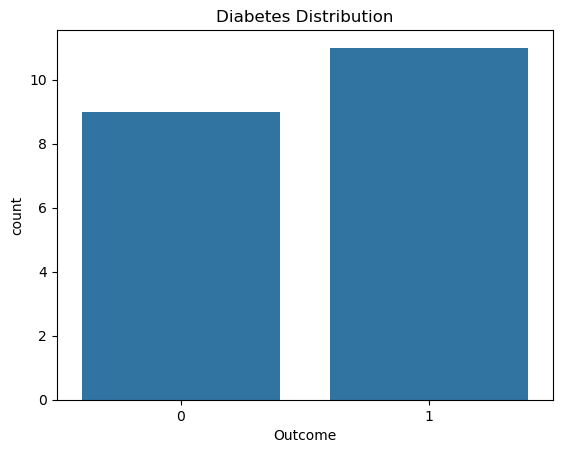

In [18]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

# Histogram 


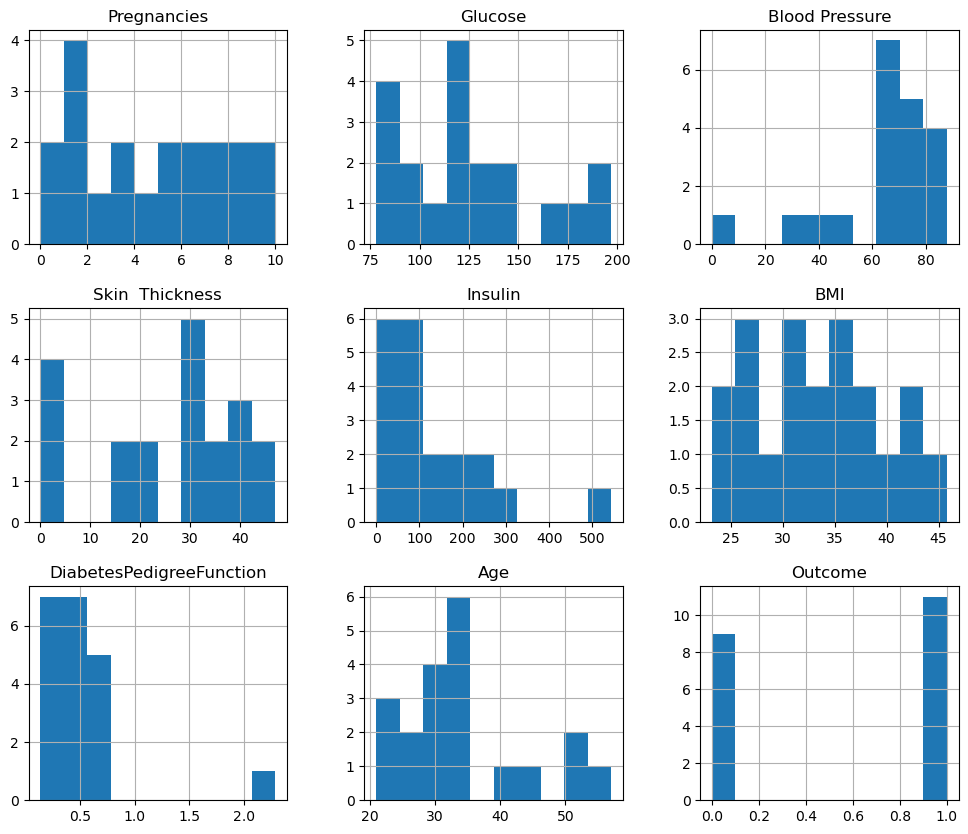

In [19]:
df.hist(figsize=(12,10))
plt.show()        

# Correlation heatmap 

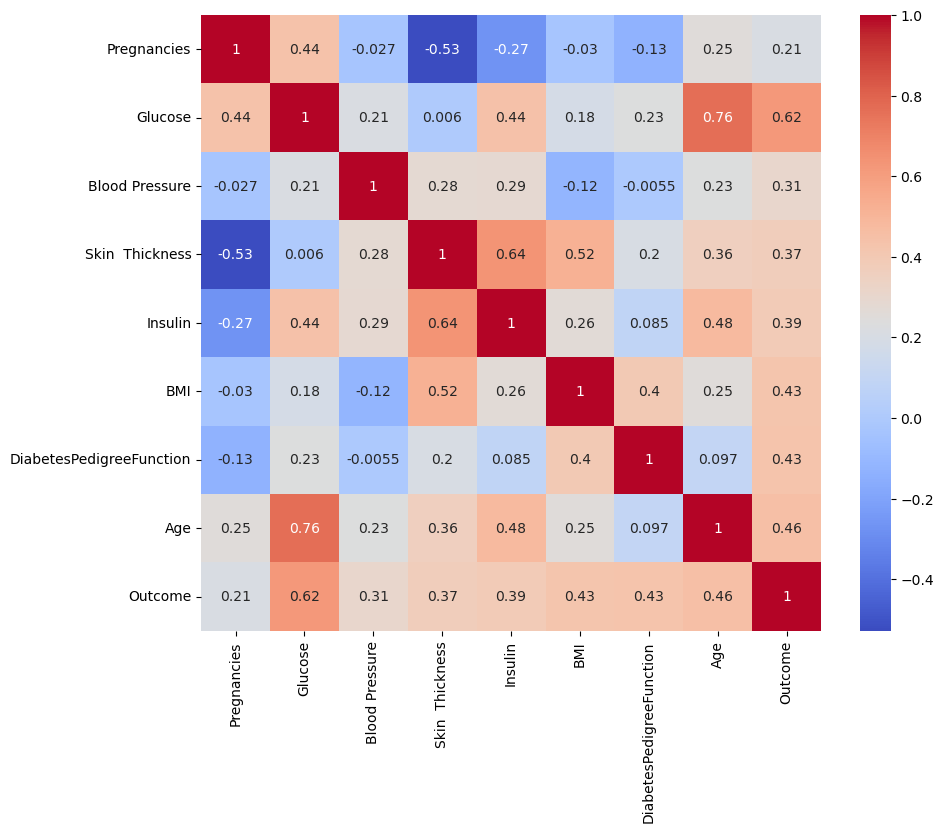

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Box Plot 

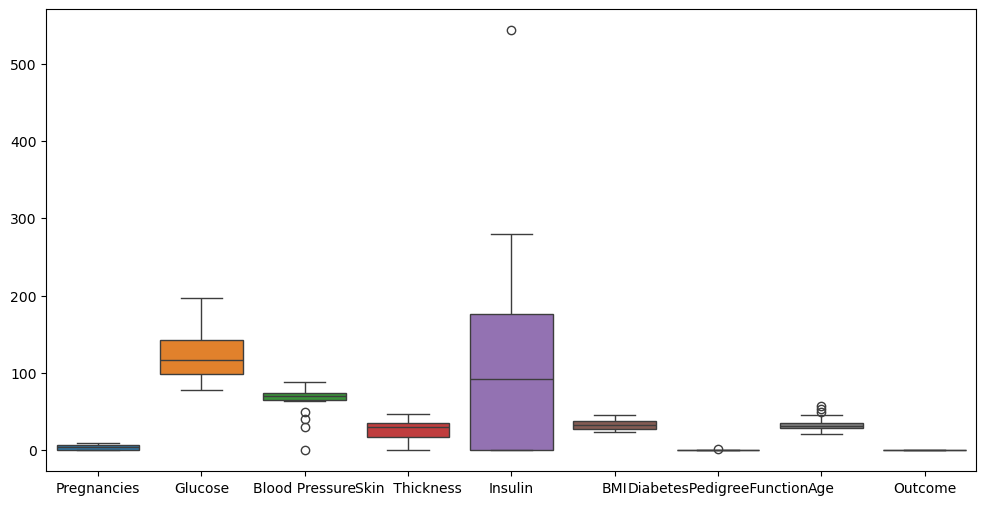

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

# Separate Features and Target 

In [22]:
X=df.drop("Outcome", axis=1)
Y=df["Outcome"]

In [24]:
X

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
5,5,116,74,0,0,25.6,0.201,30
6,3,78,50,32,88,31.0,0.248,26
7,10,115,0,0,0,35.3,0.134,29
8,2,197,70,45,543,30.5,0.158,53
9,4,125,80,30,120,32.8,0.443,41


In [25]:
Y

0     1
1     0
2     1
3     0
4     1
5     0
6     1
7     0
8     1
9     0
10    1
11    0
12    1
13    0
14    1
15    1
16    0
17    1
18    0
19    1
Name: Outcome, dtype: int64

# Feature Scalling 

In [26]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [27]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [28]:
X

array([[ 0.50245943,  0.61927402,  0.36192079,  0.6404542 , -0.94842995,
         0.05762288,  0.24284854,  1.61998468],
       [-1.0677263 , -1.14209227,  0.06647525,  0.24224434, -0.94842995,
        -1.01800418, -0.37235291, -0.32195279],
       [ 1.13053373,  1.59781085, -0.0320066 , -1.68243669, -0.94842995,
        -1.52508551,  0.34315313, -0.21974556],
       [-1.0677263 , -1.03025949,  0.06647525, -0.15596553, -0.21856982,
        -0.78751267, -0.78248721, -1.34402515],
       [-1.38176344,  0.31173388, -1.21378877,  0.6404542 ,  0.35600093,
         1.51740246,  3.94520219, -0.11753832],
       [ 0.18842229, -0.27538822,  0.46040264, -1.68243669, -0.94842995,
        -1.17166519, -0.70670152, -0.42416003],
       [-0.43965201, -1.33779964, -0.72137953,  0.44134927, -0.26515663,
        -0.34189574, -0.60193895, -0.83298897],
       [ 1.75860802, -0.30334642, -3.18342572, -1.68243669, -0.94842995,
         0.31884659, -0.8560439 , -0.52636726],
       [-0.75368915,  1.98922559

# Split Dataset  

In [30]:
X_train,X_test,y_train,y_test= train_test_split(X,Y,test_size=0.20,random_state=42)
X_train

array([[-0.75368915,  1.98922559,  0.26343894,  1.30413731,  3.267677  ,
        -0.41872625, -0.80254812,  1.92660639],
       [ 0.18842229, -0.27538822,  0.46040264, -1.68243669, -0.94842995,
        -1.17166519, -0.70670152, -0.42416003],
       [ 0.81649658, -0.72271935,  0.06647525, -0.35507046, -0.2496277 ,
        -0.49555675, -0.07589714, -0.21974556],
       [-1.0677263 , -1.03025949,  0.06647525, -0.15596553, -0.21856982,
        -0.78751267, -0.78248721, -1.34402515],
       [-0.43965201, -1.25392505,  0.36192079, -0.48780709, -0.35833027,
        -1.03337028, -0.52392428, -1.03740344],
       [-1.0677263 , -0.80659393,  0.06647525, -0.68691202,  0.13859578,
        -1.54045161, -0.06921016, -1.24181791],
       [-1.0677263 , -0.63884476, -1.70619801,  0.83955914, -0.30397898,
         1.54813466, -0.74682335, -0.11753832],
       [ 1.13053373,  1.59781085, -0.0320066 , -1.68243669, -0.94842995,
        -1.52508551,  0.34315313, -0.21974556],
       [-0.12561486, -0.02376447

In [31]:
X_test

array([[ 0.50245943,  0.61927402,  0.36192079,  0.6404542 , -0.94842995,
         0.05762288,  0.24284854,  1.61998468],
       [ 1.13053373,  1.96126739,  0.55888449,  0.24224434,  1.22562152,
         0.65690081,  0.19381075,  2.33543533],
       [ 0.81649658,  0.00419373,  1.14977557,  1.03866407,  0.87622039,
         0.93349063,  0.41448083, -0.73078173],
       [-1.0677263 , -1.14209227,  0.06647525,  0.24224434, -0.94842995,
        -1.01800418, -0.37235291, -0.32195279]])

In [32]:
y_train

8     1
5     0
11    0
3     0
18    0
16    0
13    0
2     1
9     0
19    1
4     1
12    1
7     0
10    1
14    1
6     1
Name: Outcome, dtype: int64

In [33]:
y_test

0     1
17    1
15    1
1     0
Name: Outcome, dtype: int64

# Build the Machine Learning Model 

model=LogisticRegression()
model.fit(X_train,y_train)

# Make Predictions 

In [35]:
y_pred=model.predict(X_test)
y_pred

array([1, 1, 1, 0])

# Calculate Accuracy 

In [36]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


# Confusion Matrix  

In [37]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1 0]
 [0 3]]


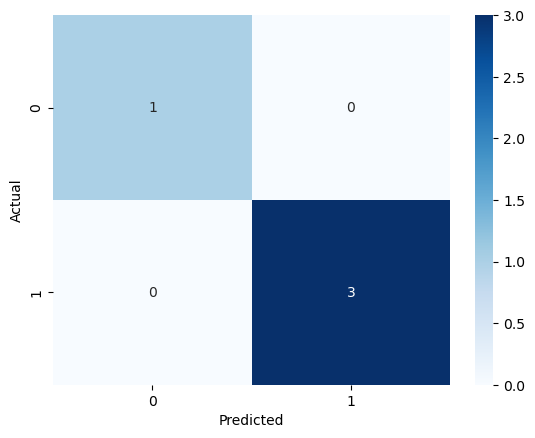

In [38]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report 

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Predict New Patient Data

In [42]:
new_patient=[[6,148,72,0,35,33.6,0.627,50]]
new_patient=scaler.transform(new_patient)
prediction=model.predict(new_patient)
if prediction[0]==1:
    print("Patient is Diabetic")
else:
    print("Patient is not Diabetic")

Patient is Diabetic


C:\Users\aisha\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Saved the Trained Model 

In [43]:
import joblib
joblib.dump(model,"diabetes_prediction_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']